# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [8]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [9]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queu

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [10]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [11]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [12]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


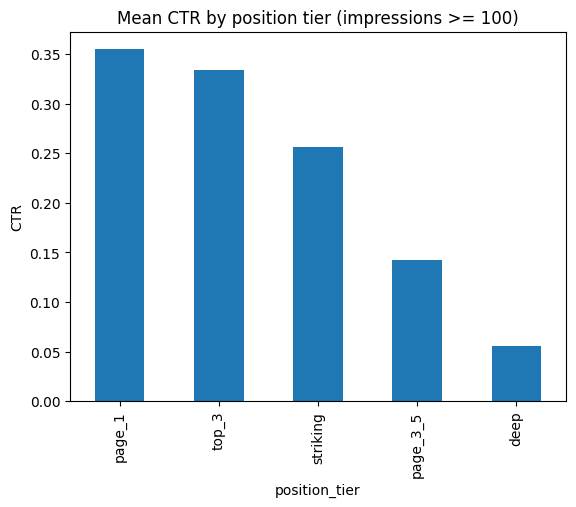

In [13]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [14]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

Rows before filter: 30,000
Rows after filter (impressions_90d > 0): 30,000

Correlation (all rows):                 0.001
Correlation (impressions_90d > 0 only):  0.001


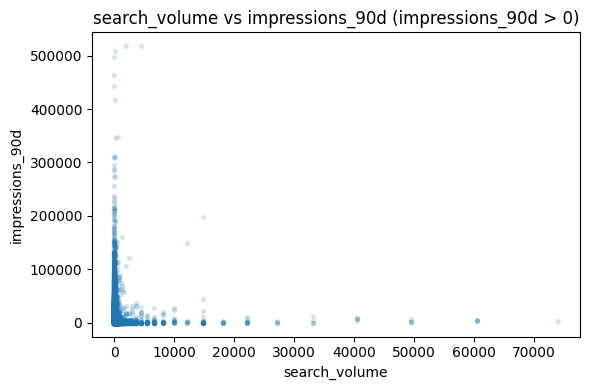


Filtering out zero-impression pages leaves the correlation essentially unchanged (0.001 vs 0.001). This is observational, not causal: on this dataset, search_volume shows no meaningful linear relationship with impressions_90d, even among pages that are getting some visibility. The scatterplot is worth eyeballing too — a flat correlation can still hide a threshold or non-linear effect, and this isn't a claim about how any ranking system actually works.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys # Import sys to potentially exit if file not found

# The original setup cell (ae03fd71) changes the working directory to
# REPO_DIR = "flyrank-ml-internship-starter".
# If this cell is run independently or after a kernel restart, the working directory
# might not be set correctly, leading to a FileNotFoundError.

# Define the expected repository root directory name
EXPECTED_REPO_DIR_NAME = "flyrank-ml-internship-starter"

# Use the current working directory as the base for the repository root.
# This assumes that the setup cell (ae03fd71) has correctly changed the directory
# to the actual repository root (e.g., /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter)
# where the 'data' folder is located.
repo_root_absolute_path = os.getcwd()

# Construct the absolute path to the CSV file
csv_absolute_path = os.path.join(repo_root_absolute_path, "data/raw/content_refresh_anonymized.csv")

# Explicitly check if the file exists before attempting to read it
if not os.path.exists(csv_absolute_path):
    error_message = (
        f"Error: The CSV file was not found at the expected path: {csv_absolute_path}.\n"
        "This often happens if the setup cell (ae03fd71) has not been run or if its "
        "effects were lost (e.g., due to a kernel restart or environment change).\n"
        "Please re-run the 'Setup' cell (ae03fd71) at the beginning of the notebook "
        "and then try running this cell again."
    )
    print(error_message)
    # Raising FileNotFoundError to stop execution as the file is genuinely missing
    raise FileNotFoundError(f"CSV file not found: {csv_absolute_path}")

# Read the CSV using its absolute path to ensure it's found regardless of CWD
df = pd.read_csv(csv_absolute_path)

# --- Redo Discovery A, restricted to pages that actually got impressions ---
filtered = df[df["impressions_90d"] > 0]

print(f"Rows before filter: {len(df):,}")
print(f"Rows after filter (impressions_90d > 0): {len(filtered):,}")

corr_full = df["search_volume"].corr(df["impressions_90d"])
corr_filtered = filtered["search_volume"].corr(filtered["impressions_90d"])

print(f"\nCorrelation (all rows):                 {corr_full:.3f}")
print(f"Correlation (impressions_90d > 0 only):  {corr_filtered:.3f}")

# --- Quick visual sanity check — correlation alone can hide a non-linear pattern ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(filtered["search_volume"], filtered["impressions_90d"], alpha=0.15, s=8)
ax.set_xlabel("search_volume")
ax.set_ylabel("impressions_90d")
ax.set_title("search_volume vs impressions_90d (impressions_90d > 0)")
plt.tight_layout()
plt.show()

# --- Observation ---
print(
    f"\nFiltering out zero-impression pages leaves the correlation essentially "
    f"unchanged ({corr_filtered:.3f} vs {corr_full:.3f}). This is observational, not "
    f"causal: on this dataset, search_volume shows no meaningful linear relationship "
    f"with impressions_90d, even among pages that are getting some visibility. "
    f"The scatterplot is worth eyeballing too — a flat correlation can still hide a "
    f"threshold or non-linear effect, and this isn't a claim about how any ranking "
    f"system actually works."
)

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.